<a href="https://colab.research.google.com/github/Echester97/Machine_learning/blob/Main-branch/Problema_del_gradiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Definición de los array x, y
x = np.linspace(-50, 51, num=1001).reshape(-1,1)
y = (12*x + 1).reshape(-1,1)

#Concatenación de los arrays
df = np.concatenate((x,y), axis=1)



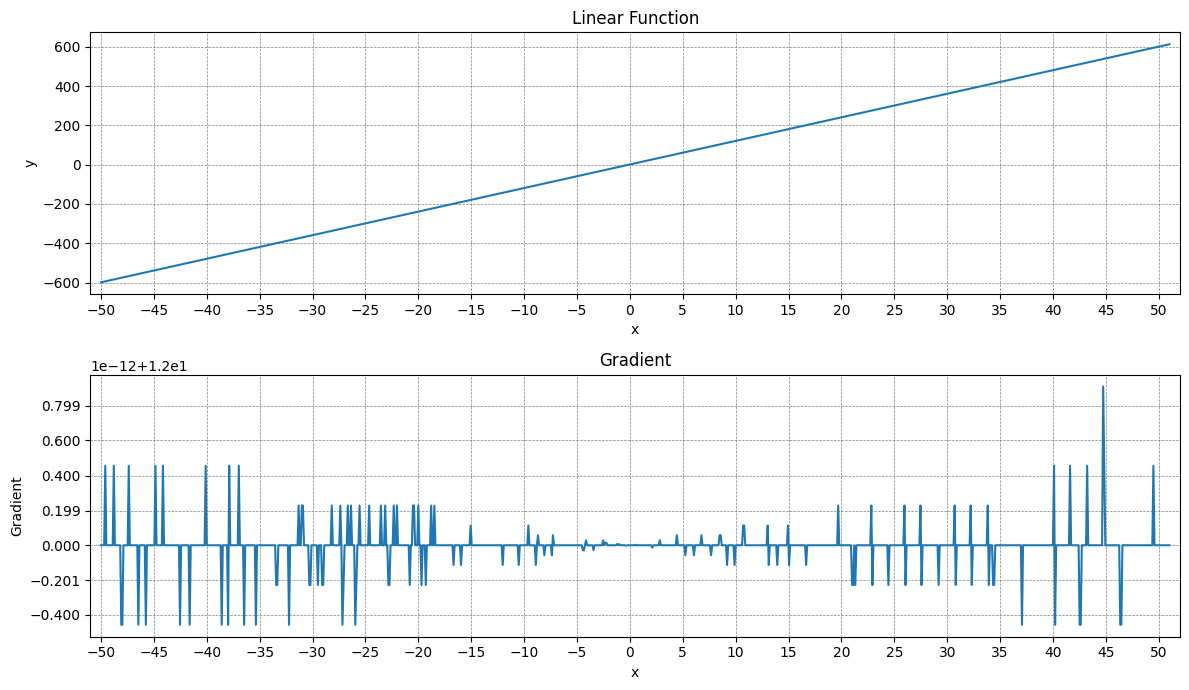

In [64]:
# Extraer columnas
x = df[:, 0]
y = df[:, 1]

# Calcular el gradiente
da = np.gradient(y, x)

#Plotting
fig, axes = plt.subplots(2,figsize=(12, 7))
axes[0].plot(x, y)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_xlim(-51, 52)
axes[0].set_xticks(np.arange(-50, 52, 5))
axes[0].set_title('Linear Function')
axes[0].grid(True, linestyle='--', color='gray', linewidth=0.5)
axes[1].plot(x, da)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Gradient')
axes[1].set_xlim(-51, 52)
axes[1].set_xticks(np.arange(-50, 52, 5))
axes[1].set_title('Gradient')
axes[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
fig.tight_layout()
plt.show()

In [65]:
def compute_gradient(function, x_range = (-50, 50.1, 0.1)):
  """
  Calcula el gradiente utilizando la cantidad de cambio.

  Parameters
  -- -- -- -- -- -- -- --
  function: function
  La función que quieres encontrar, la que devuelve el ndarray de y si pones el ndarray de x.
  x_range: tuple
  Especifica el rango del mismo modo que el argumento np.range().

  Returns
  -- -- -- -- -- -- -- --
  array_xy: ndarray, shape(n, 2)
  Combina x e y.n depende de x_rango.
  gradient: ndarray, shape(n - 1, )
  Gradiente de una función.El elemento se reduce en uno para tomar la diferencia.
  """
  x  = np.arange(*x_range)
  y = function(x)
  gradient = np.gradient(y, x)
  array_xy = np.column_stack((x, y))
  return array_xy, gradient


def function1(array_x):
  return array_x**2

def function2(array_x):
  return 2*array_x**2 + 2*array_x

def function3(array_x):
  return np.sin(12 * array_x)

array_xy1, gradient1 = compute_gradient(function1)
array_xy2, gradient2 = compute_gradient(function2)
array_xy3, gradient3 = compute_gradient(function3, (0, 50.1, 0.01))



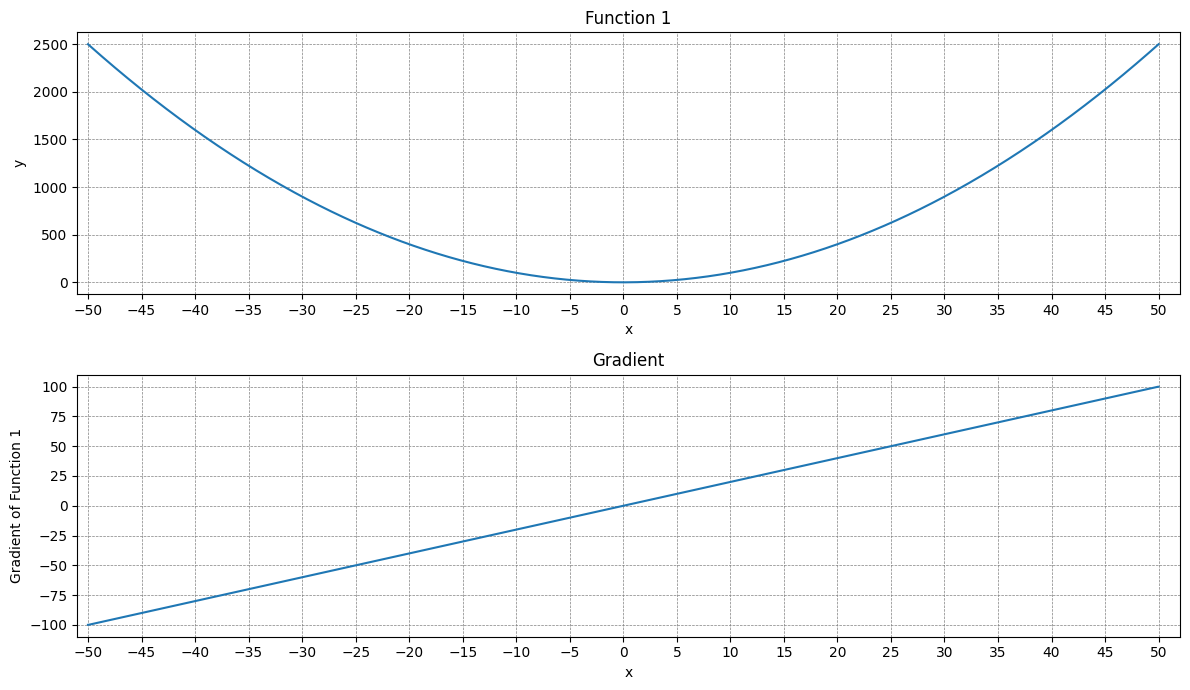

In [66]:
# Plotting function1
x = array_xy1[:, 0]
y = array_xy1[:, 1]

# Subplot 1: Function 1
fig, axes = plt.subplots(2,figsize=(12, 7))
axes[0].plot(x, y)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_xlim(-51, 52)
axes[0].set_xticks(np.arange(-50, 52, 5))
axes[0].set_title('Function 1')
axes[0].grid(True, linestyle='--', color='gray', linewidth=0.5)

# Subplot 2: Gradient of function 1
axes[1].plot(x, gradient1)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Gradient of Function 1')
axes[1].set_xlim(-51, 52)
axes[1].set_xticks(np.arange(-50, 52, 5))
axes[1].set_title('Gradient')
axes[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
fig.tight_layout()
plt.show()


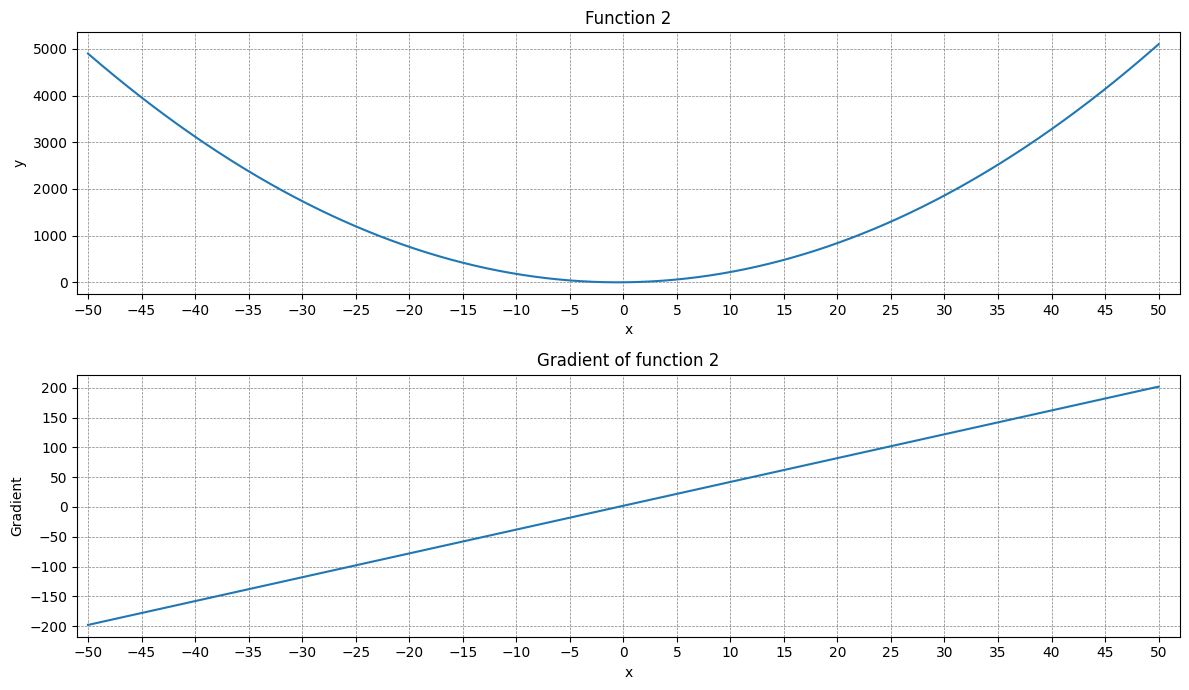

In [67]:
# Plotting function 2
x2 = array_xy2[:, 0]
y2 = array_xy2[:, 1]

# Subplot 1: Function 2
fig, axes = plt.subplots(2,figsize=(12, 7))
axes[0].plot(x2, y2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_xlim(-51, 52)
axes[0].set_xticks(np.arange(-50, 52, 5))
axes[0].set_title('Function 2')
axes[0].grid(True, linestyle='--', color='gray', linewidth=0.5)

# Subplot 2: Gradiente of function 2
axes[1].plot(x2, gradient2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Gradient')
axes[1].set_xlim(-51, 52)
axes[1].set_xticks(np.arange(-50, 52, 5))
axes[1].set_title('Gradient of function 2')
axes[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
fig.tight_layout()
plt.show()

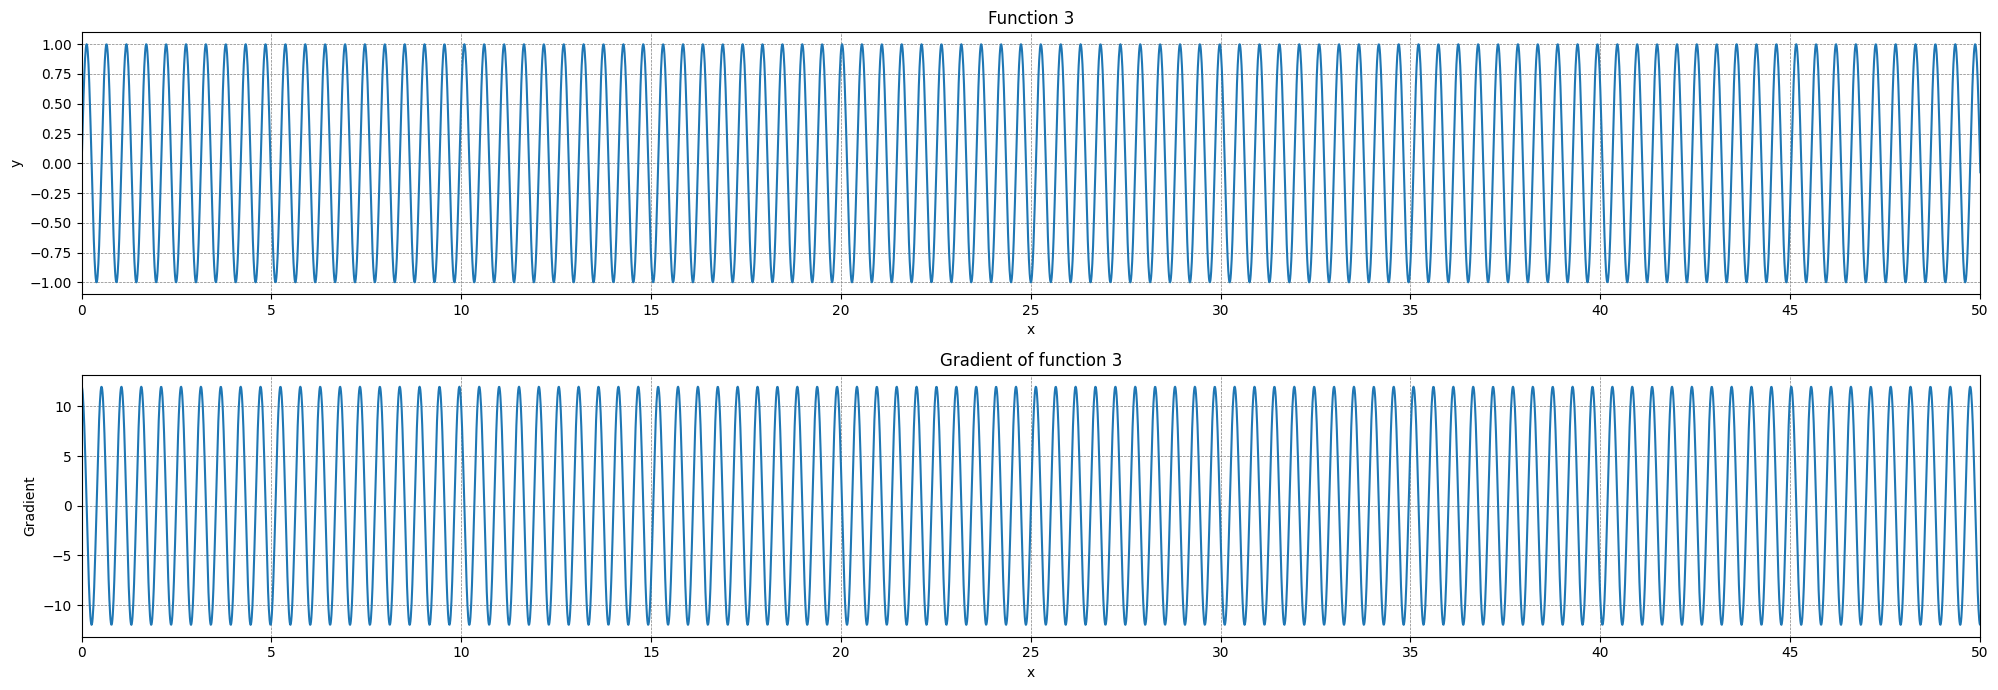

In [79]:
# Plotting function 3
x3 = array_xy3[:, 0]
y3 = array_xy3[:, 1]

# Subplot 1: Function
fig, axes = plt.subplots(2,figsize=(20, 7))
axes[0].plot(x3, y3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_xlim(0, 50)
axes[0].set_xticks(np.arange(0, 51, 5))
axes[0].set_title('Function 3')
axes[0].grid(True, linestyle='--', color='gray', linewidth=0.5)

# Subplot 2: Gradiente of function 3
axes[1].plot(x3, gradient3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Gradient')
axes[1].set_xlim(0, 50)
axes[1].set_xticks(np.arange(0, 51, 5))
axes[1].set_title('Gradient of function 3')
axes[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
fig.tight_layout()
plt.show()

In [78]:
# Encontrar el valor minimo y las pendientes
def compute_min_and_slopes(function, x_range=(-50, 50.1, 0.001)):
  """
  Encuentra el valor mínimo de la función y sus pendientes adyacentes.

  Parameters
  -- -- -- -- -- -- -- --
  function: function
      Funcioón que devuelve y dado un array de x
  x_range: tuple
      rango (start, stop, step) para generar x con np.arange

  Returns
  -------

  x_min: float
      El valor mínimo de x donde la función alcanza su mínimo.
  y_min: float
      Valor mínimo de la función en x_min.
  slope_before: float
      Pendiente antes de x_min.
  slope_after: float
      Pendiente después de x_min.
  """
  # Generar x e y
  x = np.arange(*x_range)
  y = function(x)

  # Calcular la gradiente
  gradiente = np.gradient(y, x)

  # Encontrar el mínimo
  y_min = np.min(y)
  x_min = x[np.argmin(y)]

  # Obtener las pendientes adyacentes
  slope_before = gradiente[np.argmin(y) - 1]
  slope_after = gradiente[np.argmin(y) + 1]

  return round(x_min), round(y_min), round(slope_before, 4), round(slope_after, 4)

x_min1, y_min1, slope_before1, slope_after1 = compute_min_and_slopes(function1)
x_min2, y_min2, slope_before2, slope_after2 = compute_min_and_slopes(function2)
x_min3, y_min3, slope_before3, slope_after3 = compute_min_and_slopes(function3, (0, 50.1, 0.001))

print(f"Function 1: x_min = {x_min1}, y_min = {y_min1}, slope_before = {slope_before1}, slope_after = {slope_after1}")
print(f"Function 2: x_min = {x_min2}, y_min = {y_min2}, slope_before = {slope_before2}, slope_after = {slope_after2}")
print(f"Function 3: x_min = {x_min3}, y_min = {y_min3}, slope_before = {slope_before3}, slope_after = {slope_after3}")




Function 1: x_min = 0, y_min = 0, slope_before = -0.002, slope_after = 0.002
Function 2: x_min = -1, y_min = 0, slope_before = -0.004, slope_after = 0.004
Function 3: x_min = 42, y_min = -1, slope_before = -0.1443, slope_after = 0.1437
